<a href="https://colab.research.google.com/github/syedmahmoodiagents/Reinforce/blob/main/Frozen_lake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lets try to install the library called Gymnasium

In [ ]:
# !pip install gymnasium --q

In [1]:
import gymnasium as gym

In [2]:
# import gym
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
gym.envs.registry.keys()

dict_keys(['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v3', 'LunarLanderContinuous-v3', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v3', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v1', 'CliffWalkingSlippery-v1', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Reacher-v5', 'Pusher-v2', 'Pusher-v4', 'Pusher-v5', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'HalfCheetah-v5', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Hopper-v5', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Swimmer-v5', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Walker2d-v5', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'Humanoid-v2', 'Humanoid-v3', 

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

In [ ]:
env.reset()

(0, {'prob': 1})

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
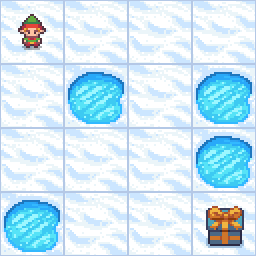

In [ ]:
env.render()

In [ ]:
env.observation_space

Discrete(16)

In [ ]:
env.observation_space.n

np.int64(16)

In [ ]:
env.action_space.n

np.int64(4)

In [ ]:
env.step(1)

(4, 0, False, False, {'prob': 1.0})

In [ ]:
env.reset()

(0, {'prob': 1})

In [ ]:
act = env.action_space.sample() # for random action
env.step(act)

(12, 0, True, False, {'prob': 1.0})

# Enabling the slippery environment

In [ ]:
env2 = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

In [ ]:
env2.reset()

(0, {'prob': 1})

In [ ]:
env2.step(2)

(4, 0, False, False, {'prob': 0.33333333333333337})

In [ ]:
env2.step(2)

(5, 0, True, False, {'prob': 0.3333333333333333})

In [ ]:
env2.reset()

(0, {'prob': 1})

In [ ]:
env2.unwrapped.P[14][2]

[(0.33333333333333337, 14, 0, False),
 (0.3333333333333333, 15, 1, True),
 (0.33333333333333337, 10, 0, False)]

In [ ]:
prob, next_state, reward, done = env2.unwrapped.P[14][2][2]

In [ ]:
for prob, next_state, reward, done in env2.unwrapped.P[14][2]:
    print(f"Probability: {prob}, Next State: {next_state}, Reward: {reward}, Done: {done}")

Probability: 0.33333333333333337, Next State: 14, Reward: 0, Done: False
Probability: 0.3333333333333333, Next State: 15, Reward: 1, Done: True
Probability: 0.33333333333333337, Next State: 10, Reward: 0, Done: False


In [ ]:
Vmax = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

In [ ]:
value = 0
for prob, next_state, reward, done in env2.unwrapped.P[14][2]:
    value = value + prob * (reward + 0.9 * Vmax[next_state])
    print(value)

0.0
0.3333333333333333
0.3333333333333333


In [ ]:
ls=[]
for a in range(4):
  value = 0
  for prob, next_state, reward, done in env2.unwrapped.P[14][a]:
      value = value + prob * (reward + 0.9 * Vmax[next_state])
  # print(value)
  ls.append(value)
  print("----")

----
----
----
----


In [ ]:
ls

[0.0, 0.33333333333333337, 0.3333333333333333, 0.33333333333333337]

In [ ]:
max(ls)

0.33333333333333337

In [ ]:
Vmax[14] = max(ls)

In [ ]:
ls=[]
for a in range(4):
  value = 0
  for prob, next_state, reward, done in env2.unwrapped.P[14][a]:
      value = value + prob * (reward + 0.9 * Vmax[next_state])
  # print(value)
  ls.append(value)
Vmax[14] = max(ls)

In [ ]:
Vmax = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
for s in range(16):
  ls=[]
  for a in range(4):
    value = 0
    for prob, next_state, reward, done in env2.unwrapped.P[s][a]:
        value = value + prob * (reward + 0.9 * Vmax[next_state])
    # print(value)
    ls.append(value)
  Vmax[s] = max(ls)

V(14) = v + p*(R + Vprev(15))

In [ ]:
Vmax

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.33333333333333337,
 0.0]

In [ ]:
Vmax = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
for i in range(100):
        for s in range(16):
                ls=[]
                for a in range(4):
                        value = 0
                        for prob, next_state, reward, done in env2.unwrapped.P[s][a]:
                                value = value + prob * (reward + 0.9 * Vmax[next_state])
                        ls.append(value)
                Vmax[s] = max(ls)

In [ ]:
Vmax

[0.06889090221153527,
 0.061414569559865656,
 0.07440976074513862,
 0.05580732015188351,
 0.09185453780109856,
 0.0,
 0.11220820587305609,
 0.0,
 0.1454363533655531,
 0.2474969538304731,
 0.2996175922628153,
 0.0,
 0.0,
 0.37993590067219113,
 0.6390201478867472,
 0.0]

In [ ]:
snv = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
action = snv.reset()

In [ ]:
action

0

In [ ]:
snv.step(action)

(0, 0.0, False, {'prob': 1.0})

In [ ]:
image_array = snv.render()

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
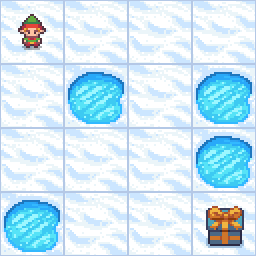

In [ ]:
image_array[0]

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
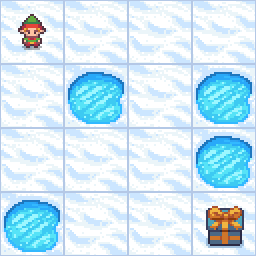

In [ ]:
np.squeeze(image_array[0])

In [ ]:
# plt.imshow(np.squeeze(image_array))

In [ ]:
snv.action_space.n # Actions

4

In [ ]:
snv.observation_space.n # States (Positions)

16

In [ ]:
snv.reset()

0

In [ ]:
snv.step(1)

(4, 0.0, False, {'prob': 1.0})

In [ ]:
snv.step(2)

(5, 0.0, True, {'prob': 1.0, 'TimeLimit.truncated': False})

In [ ]:
snv.step(3)

(5, 0, True, {'prob': 1.0, 'TimeLimit.truncated': False})

# All the possibilities

In [ ]:
snv.P[14][2]

[(1.0, 15, 1.0, True)]

In [ ]:
snv.P[14]

{0: [(1.0, 13, 0.0, False)],
 1: [(1.0, 14, 0.0, False)],
 2: [(1.0, 15, 1.0, True)],
 3: [(1.0, 10, 0.0, False)]}

In [ ]:
snv.P[14][2]

[(1.0, 15, 1.0, True)]

In [ ]:
for k in snv.P[14][2]:
  print(k)

(1.0, 15, 1.0, True)


# New Environment

In [ ]:
vne = gym.make("FrozenLake-v1", is_slippery=True)

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
vne.observation_space

Discrete(16)

In [ ]:
vne.action_space

Discrete(4)

In [ ]:
vne.action_space.n

4

In [ ]:
vne.action_space.sample()

2

In [ ]:
vne.reset()

0

In [ ]:
vne.step(2)

(4, 0.0, False, {'prob': 0.3333333333333333})

In [ ]:
vne.P[14][2]

[(0.3333333333333333, 14, 0.0, False),
 (0.3333333333333333, 15, 1.0, True),
 (0.3333333333333333, 10, 0.0, False)]

In [ ]:
for k in vne.P[14][2]:
  print(k)

(0.3333333333333333, 14, 0.0, False)
(0.3333333333333333, 15, 1.0, True)
(0.3333333333333333, 10, 0.0, False)


In [ ]:
vne.P

{0: {0: [(0.3333333333333333, 0, 0.0, False),
   (0.3333333333333333, 0, 0.0, False),
   (0.3333333333333333, 4, 0.0, False)],
  1: [(0.3333333333333333, 0, 0.0, False),
   (0.3333333333333333, 4, 0.0, False),
   (0.3333333333333333, 1, 0.0, False)],
  2: [(0.3333333333333333, 4, 0.0, False),
   (0.3333333333333333, 1, 0.0, False),
   (0.3333333333333333, 0, 0.0, False)],
  3: [(0.3333333333333333, 1, 0.0, False),
   (0.3333333333333333, 0, 0.0, False),
   (0.3333333333333333, 0, 0.0, False)]},
 1: {0: [(0.3333333333333333, 1, 0.0, False),
   (0.3333333333333333, 0, 0.0, False),
   (0.3333333333333333, 5, 0.0, True)],
  1: [(0.3333333333333333, 0, 0.0, False),
   (0.3333333333333333, 5, 0.0, True),
   (0.3333333333333333, 2, 0.0, False)],
  2: [(0.3333333333333333, 5, 0.0, True),
   (0.3333333333333333, 2, 0.0, False),
   (0.3333333333333333, 1, 0.0, False)],
  3: [(0.3333333333333333, 2, 0.0, False),
   (0.3333333333333333, 1, 0.0, False),
   (0.3333333333333333, 0, 0.0, False)]},
 2:

In [ ]:
for prob, next_state, reward, done in vne.P[14][2]:
    print(f"Probability: {prob}, Next State: {next_state}, Reward: {reward}, Done: {done}")

Probability: 0.3333333333333333, Next State: 14, Reward: 0.0, Done: False
Probability: 0.3333333333333333, Next State: 15, Reward: 1.0, Done: True
Probability: 0.3333333333333333, Next State: 10, Reward: 0.0, Done: False


In [ ]:
V = np.zeros(16)

In [ ]:
V

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
0.9*V[15]

np.float64(0.0)

In [ ]:
for prob,next_state,reward,terminated in vne.P[14][2]:
  print(prob,next_state,reward,terminated)

0.3333333333333333 14 0.0 False
0.3333333333333333 15 1.0 True
0.3333333333333333 10 0.0 False


In [ ]:
value = 0
for prob, next_state, reward, done in vne.P[14][2]:
    value = value + prob * (reward + 0.9 * V[next_state])
    print(value)

0.0
0.3333333333333333
0.3333333333333333


In [ ]:
print(value)

0.3333333333333333


### till this point

In [ ]:
# env.P[state][action]

In [ ]:
vne.P[1][0][2]

(0.3333333333333333, 5, 0.0, True)

In [ ]:
probability, next_state, reward, terminate = vne.P[1][0][2]

In [ ]:
dic = vne.P[0]

In [ ]:
dic.keys()

dict_keys([0, 1, 2, 3])

In [ ]:
dic.values()

dict_values([[(1.0, 0, 0.0, False)], [(1.0, 4, 0.0, False)], [(1.0, 1, 0.0, False)], [(1.0, 0, 0.0, False)]])

# Using Gymnasium

In [ ]:
!pip install gymnasium --q

In [ ]:
import gymnasium

In [ ]:
envn = gymnasium.make("FrozenLake-v1", is_slippery=False, render_mode='rgb_array')

In [ ]:

class OneHotEncodingWrapper(gymnasium.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        assert isinstance(env.observation_space, Discrete)
        self.observation_space = Box(0, 1, (env.observation_space.n,), dtype=np.float32)

    def observation(self, obs):
        return np.eye(self.observation_space.shape[0], dtype=np.float32)[obs]


envn = OneHotEncodingWrapper(envn) # Apply the wrapper



In [ ]:
envn.reset()
image_array_gymnasium = envn.render()

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
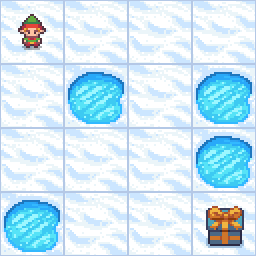

In [ ]:
image_array_gymnasium

# Using Stable-Baseline3

In [ ]:
!pip install stable-baselines3[extra] --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 10.9 MB/s eta 0:00:00


In [ ]:
from gymnasium.spaces import Discrete, Box

In [ ]:
!pip install shimmy>=2.0

In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from stable_baselines3 import DQN

In [ ]:
envn = gymnasium.make("FrozenLake-v1", is_slippery=False)

In [ ]:
model = DQN("MlpPolicy", envn, verbose=1, learning_rate=0.001, buffer_size=10)
model.learn(total_timesteps=50) # Usually it should be around 50000

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.25     |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 6936     |
|    time_elapsed     | 0        |
|    total_timesteps  | 25       |
----------------------------------


In [ ]:


class OneHotEncodingWrapper(gymnasium.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        assert isinstance(env.observation_space, Discrete)
        self.observation_space = gymnasium.spaces.Box(0, 1, (env.observation_space.n,), dtype=np.float32)

    def observation(self, obs):
        return np.eye(self.observation_space.shape[0], dtype=np.float32)[obs]

In [ ]:

envn = OneHotEncodingWrapper(envn) # Apply the wrapper

In [ ]:
modeln = DQN("MlpPolicy", envn, verbose=1, learning_rate=0.001, buffer_size=10)
modeln.learn(total_timesteps=50) # Increased timesteps for better learning upto 50k with buffer as 5k

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 11.5     |
|    ep_rew_mean      | 0.25     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5238     |
|    time_elapsed     | 0        |
|    total_timesteps  | 46       |
----------------------------------


In [ ]:
# Evaluate
obs, info = envn.reset()
for _ in range(10):
    done, truncated = False, False
    total_reward = 0
    # Re-initialize environment for each episode
    obs, info = envn.reset()
    # Get the initial integer state from the observation (assuming one-hot encoding)
    # This might need adjustment depending on the exact structure of the wrapped observation
    state = np.argmax(obs)

    while not (done or truncated):
        # Model predicts action based on the one-hot encoded observation
        action, _ = modeln.predict(obs)

        # Convert action from numpy array to integer
        action = int(action)

        # Use the environment's transition probabilities from the unwrapped environment
        if state in envn.unwrapped.P and action in envn.unwrapped.P[state]:
            transitions = envn.unwrapped.P[state][action]
            # For deterministic environment (is_slippery=False), there should be only one transition
            if len(transitions) > 0:
                prob, next_state, reward, terminated = transitions[0]
                # Update the current state and total reward
                state = next_state
                total_reward += reward
                done = terminated
                # Update the observation for the next prediction
                # Convert the integer state back to one-hot encoding for the model
                obs = np.eye(envn.observation_space.shape[0], dtype=np.float32)[state]
            else:
                # Should not happen in a non-slippery deterministic environment
                done = True
        else:
             # If state or action is not in P, something is wrong or episode ended unexpectedly
             done = True

        # Check for truncation (e.g., due to time limit) - not explicitly handled in this basic loop
        # but included in the while condition for completeness.

    print("Episode reward:", total_reward)

Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0
Episode reward: 0.0


In [ ]:
image_array_gymnasium

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
snv = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

In [ ]:
# Reset the environment to get the initial state
initial_state = snv.reset() # Modified to expect a single return value
print(f"Initial state: {initial_state}")

# Take a step (you can choose any valid action, e.g., 0 for left)
action_to_take = 2 # Replace with the desired action

# The step method also returns a tuple in the new API, let's check the number of values it returns
step_result = snv.step(action_to_take)

Initial state: 0


In [ ]:
# Check the length of the step_result tuple to see if it matches the new API (5 values) or old API (4 values)
if len(step_result) == 5:
    next_state, reward, terminated, truncated, info = step_result
    # truncated = True means the episode ended before a terminal state was reached
    print(5)
elif len(step_result) == 4:
    print(4)
    # Assuming old API return signature: next_state, reward, done, info
    next_state, reward, done, info = step_result
    terminated = done # For compatibility with the check below
    truncated = False # Assuming no truncation in old API

4


In [ ]:
print(f"Next state after taking action {action_to_take}: {next_state}")

Next state after taking action 2: 1


In [ ]:
# Render and display the image after the step
image_array = snv.render()

In [ ]:
image_array

[array([[[180, 200, 230],
         [180, 200, 230],
         [180, 200, 230],
         ...,
         [180, 200, 230],
         [180, 200, 230],
         [180, 200, 230]],
 
        [[180, 200, 230],
         [204, 230, 255],
         [204, 230, 255],
         ...,
         [204, 230, 255],
         [204, 230, 255],
         [180, 200, 230]],
 
        [[180, 200, 230],
         [235, 245, 249],
         [204, 230, 255],
         ...,
         [204, 230, 255],
         [204, 230, 255],
         [180, 200, 230]],
 
        ...,
 
        [[180, 200, 230],
         [235, 245, 249],
         [235, 245, 249],
         ...,
         [204, 230, 255],
         [235, 245, 249],
         [180, 200, 230]],
 
        [[180, 200, 230],
         [235, 245, 249],
         [235, 245, 249],
         ...,
         [204, 230, 255],
         [204, 230, 255],
         [180, 200, 230]],
 
        [[180, 200, 230],
         [180, 200, 230],
         [180, 200, 230],
         ...,
         [180, 200, 230],
  

(256, 256, 3)
Image displayed successfully.


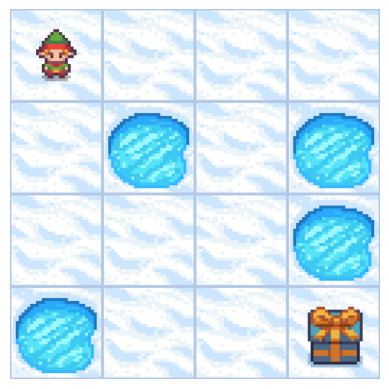

In [ ]:

# Attempt to reshape the array to remove the extra dimension
try:
    # Assuming the shape is (2, height, width, channels) and we want (height, width, channels)
    reshaped_image_array = image_array[0] # Try taking the first element of the first dimension
    print(image_array[0].shape)
    plt.imshow(reshaped_image_array)
    print("Image displayed successfully.")
except IndexError:
    # If that fails, try squeezing and then taking the first element (though squeeze should handle this)
    try:
        reshaped_image_array = np.squeeze(image_array)[0]
        plt.imshow(reshaped_image_array)
    except IndexError:
        # If both fail, try just displaying the squeezed array again
        plt.imshow(np.squeeze(image_array))


plt.axis('off') # Hide axes
plt.show()

# time.sleep(0.1) # Add a small pause

# Using Gymnasium

In [ ]:
import gymnasium
import numpy as np
from gymnasium.spaces import Discrete, Box

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
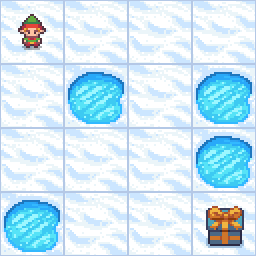

In [ ]:
image_array_gymnasium

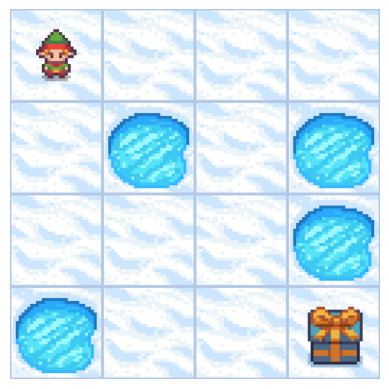

In [ ]:
# The rendered image from gymnasium might also need squeezing
plt.imshow(np.squeeze(image_array_gymnasium))
plt.axis('off') # Hide axes
plt.show()